Instalimi dhe importimi i librarive të nevojshme

In [ ]:
pip install pandas scipy seaborn matplotlib

In [6]:
import pandas as pd
import warnings
from scipy.stats import zscore
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

warnings.simplefilter(action='ignore', category=FutureWarning)

Mbledhja e të dhënave, definimi i tipeve të dhënave, kualiteti i të dhënave

In [7]:
df = pd.read_csv(r'./master.csv')

print(df.dtypes)
print(df.describe())

country                object
year                    int64
sex                    object
age                    object
suicides_no             int64
population              int64
suicides/100k pop     float64
country-year           object
HDI for year          float64
 gdp_for_year ($)      object
gdp_per_capita ($)      int64
generation             object
dtype: object
               year   suicides_no    population  suicides/100k pop  \
count  27820.000000  27820.000000  2.782000e+04       27820.000000   
mean    2001.258375    242.574407  1.844794e+06          12.816097   
std        8.469055    902.047917  3.911779e+06          18.961511   
min     1985.000000      0.000000  2.780000e+02           0.000000   
25%     1995.000000      3.000000  9.749850e+04           0.920000   
50%     2002.000000     25.000000  4.301500e+05           5.990000   
75%     2008.000000    131.000000  1.486143e+06          16.620000   
max     2016.000000  22338.000000  4.380521e+07         224.970000

Riemërimi i kolonave për përdorim më të lehtë

In [8]:
df=df.rename(columns={'sex':'gender','gdp_per_capita ($)':'gdp_per_capita',' gdp_for_year ($) ':'gdp_for_year', 'HDI for year' : 'hdi_for_year'})

Modifikimi i tipit të dhënave për kolonën 'gdp_for_year'

In [9]:
print('Kolona para modifikimit', df['gdp_for_year'].iloc[0])  
df['gdp_for_year'] = df['gdp_for_year'].str.replace(',', '').astype(int)
print('Kolona pas modifikimit', df['gdp_for_year'].iloc[0])  

Kolona para modifikimit 2,156,624,900
Kolona pas modifikimit 2156624900


Ndryshimi i dimensionalitetit

In [10]:
df = df[['country','year', 'gender', 'age', 'suicides_no','population','suicides/100k pop','gdp_for_year','gdp_per_capita','hdi_for_year']]

Menaxhimi i vlerave null

In [11]:
df = df.sort_values(by=['country', 'year'])

df['hdi_for_year'] = df.groupby('country')['hdi_for_year'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))

yearly_mean = df.groupby(['country', 'year'])['hdi_for_year'].mean().reset_index()

yearly_mean['hdi_for_year'] = yearly_mean.groupby('country')['hdi_for_year'].transform(lambda x: x.interpolate(method='linear'))

df = df.merge(yearly_mean, on=['country', 'year'], suffixes=('', '_mean'))

df['hdi_for_year'] = df['hdi_for_year'].combine_first(df['hdi_for_year_mean'])

df = df.drop(columns=['hdi_for_year_mean'])

print(df['hdi_for_year'])

0        0.619
1        0.619
2        0.619
3        0.619
4        0.619
         ...  
27815    0.675
27816    0.675
27817    0.675
27818    0.675
27819    0.675
Name: hdi_for_year, Length: 27820, dtype: float64


Mostrimi i të dhënave (10%)

In [12]:
sampled_data = df.sample(frac=0.1)
print(sampled_data)

              country  year  gender          age  suicides_no  population  \
10005         Germany  2014  female  35-54 years          801    11728001   
23867           Spain  2013    male  25-34 years          260     3221833   
19405        Portugal  1989    male  55-74 years          207      854371   
4827         Bulgaria  2008  female  35-54 years           41     1066979   
9792          Germany  1996    male   5-14 years           36     4720200   
...               ...   ...     ...          ...          ...         ...   
6181       Costa Rica  1999  female  15-24 years            8      344682   
7439          Denmark  1995  female  15-24 years            8      341800   
1114          Armenia  2002  female  15-24 years            1      294739   
24364        Suriname  2014  female  35-54 years            9       70884   
7174   Czech Republic  1996  female  55-74 years          117     1054200   

       suicides/100k pop   gdp_for_year  gdp_per_capita  hdi_for_year  
100

Validimi i vlerave duplikate <br>
Kontrollimi i kolonave specifike

In [13]:
duplicates_check=['country','year','gender','age']
duplicates=df.duplicated(subset=duplicates_check)

if duplicates.any():
    print("Duplicates found. Dropping duplicates.")
    df = df.drop_duplicates()
    print("\nCleaned DataFrame:")
    print(df)
else:
    print("No duplicates found. DataFrame remains unchanged.")

No duplicates found. DataFrame remains unchanged.


Kontrollimi i tërë dataframe-it


In [14]:
duplicates = df.duplicated()

if duplicates.any():
    print("Duplicates found.")
else:
    print("No duplicates found.")

No duplicates found.


Transformimi i kolonave specifike

In [15]:
df['total_suicides_year'] = df.groupby(["country", "year"])['suicides_no'].transform('sum')
df['total_population_year'] = df.groupby(["country", "year"])['population'].transform('sum')
df['suicides_to_population_ratio'] = df['suicides_no'] / df['population']

# Print max 2 rows from each column
print("total_suicides_year:")
print(df['total_suicides_year'].head(2))

print("\ntotal_population_year:")
print(df['total_population_year'].head(2))

print("\nsuicides_to_population_ratio:")
print(df['suicides_to_population_ratio'].head(2))


total_suicides_year:
0    73
1    73
Name: total_suicides_year, dtype: int64

total_population_year:
0    2709600
1    2709600
Name: total_population_year, dtype: int64

suicides_to_population_ratio:
0    0.000067
1    0.000052
Name: suicides_to_population_ratio, dtype: float64


Diskretizimi i perpjestimit të vetëvrasjeve me numrin e popullesisë dhe i gdp në kategori më të përshtatshme

In [16]:
ratio_bins = [-1, 0, 1e-05, 2e-05, 4e-05, 6e-05, 8e-05, float('inf')]
ratio_labels = ['None','Very Low', 'Low', 'Medium', 'High', 'Very High', 'Extreme']

df['suicides_to_population_ratio_discretize'] = pd.cut(df['suicides_to_population_ratio'], bins=ratio_bins, labels=ratio_labels)

low_threshold = df['gdp_per_capita'].quantile(0.33)
medium_threshold = df['gdp_per_capita'].quantile(0.66)
suicide_bins = [-float('inf'), low_threshold, medium_threshold, float('inf')]
suicide_labels = ['Low', 'Medium', 'High']
df['gdp_category'] = pd.cut(df['gdp_per_capita'], bins=suicide_bins, labels=suicide_labels)

print(df['gdp_category'])

0        Low
1        Low
2        Low
3        Low
4        Low
        ... 
27815    Low
27816    Low
27817    Low
27818    Low
27819    Low
Name: gdp_category, Length: 27820, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']


In [27]:
suicide_bins = [-float('inf'), 50, 500, 1000, 3000, float('inf')]
suicide_labels = ['0-50', '51-500', '501-1000','1001-3000','>=3000']
df['total_suicides_year_category'] = pd.cut(df['total_suicides_year'], bins=suicide_bins, labels=suicide_labels)

Binarizimi i kolones 'gender'

In [28]:
df['gender_encoded'] = df['gender'].map({'male': 1, 'female': 0})
print(df['gender_encoded'].unique())

[1 0]


Ruajtja e transformimeve ne nje file te ri

In [29]:
df.to_csv('cleaned_data.csv', index=False)

Outlires Detection

In [30]:
df=pd.read_csv(r'./cleaned_data.csv')


numerical_columns_country_year = ["suicides_no", "population", "suicides_to_population_ratio"]

# Group by the context
grouped_country_year = df.groupby(["country", "year"])


# Calculate z-scores within each group
def calculate_z_scores(group, numerical_columns):
    for col in numerical_columns:
        group[f"{col}_zscore"] = zscore(group[col]) if group[col].std() != 0 else 0
    return group

df = grouped_country_year.apply(calculate_z_scores, numerical_columns_country_year)

# Un-group for final result
df.reset_index(drop=True, inplace=True)


numerical_columns_country = ["gdp_for_year", "gdp_per_capita", "hdi_for_year"]

grouped_country = df.groupby(["country"])
df = grouped_country.apply(calculate_z_scores, numerical_columns_country)

# Un-group for final result
df.reset_index(drop=True, inplace=True)

# Identify outliers based on the z-score threshold
z_score_threshold = 3

outliers = df[
    (df[[f"{col}_zscore" for col in numerical_columns_country_year + numerical_columns_country]]
     .abs() > z_score_threshold).any(axis=1)
]

outliers_table = (df[
    [f"{col}_zscore" for col in numerical_columns_country_year + numerical_columns_country]
].abs() > z_score_threshold)

C:\Users\EndritHoda\AppData\Local\Temp\ipykernel_13192\1094845972.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = grouped_country_year.apply(calculate_z_scores, numerical_columns_country_year)
C:\Users\EndritHoda\AppData\Local\Temp\ipykernel_13192\1094845972.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = grouped_country.apply(calculate_z_scores, numerical_columns_country)


Display Outliers

In [31]:
print(f"Number of outliers:", outliers.shape[0])  # Number of outlier rows
print(f"Outliers\n", outliers)
columns_with_outliers = [
    col.removesuffix('_zscore') 
    for col in outliers_table[[f"{col}" for col in outliers_table.columns]].any()[lambda x: x].index.tolist()
]

print(columns_with_outliers)

Number of outliers: 24
Outliers
                             country  year  gender          age  suicides_no  \
453             Antigua and Barbuda  2004    male  35-54 years            1   
2315                        Bahamas  2002    male  35-54 years            1   
6634                         Cyprus  2000    male  35-54 years            2   
10146                       Grenada  1993    male   5-14 years            1   
10157                       Grenada  1994    male  55-74 years            1   
10212                       Grenada  2003    male  35-54 years            2   
13723                      Kiribati  1995    male  15-24 years            1   
15222                    Luxembourg  2010    male    75+ years            7   
15335                      Maldives  2003  female  35-54 years            1   
21362  Saint Vincent and Grenadines  2010    male   5-14 years            1   
21789                    Seychelles  2009    male  55-74 years            1   
21963              

Fshirja e rreshtave me outliers dhe ruajtja e rezultatit ne file te ri

In [32]:
df = df.drop(outliers.index)
df.reset_index(drop=True, inplace=True)

df.to_csv('cleaned_data_without_outliers.csv', index=False)

df=pd.read_csv(r'./cleaned_data_without_outliers.csv')


Korelacioni i Vlerave Numerike

Text(0.5, 1.0, 'Correlation Matrix')

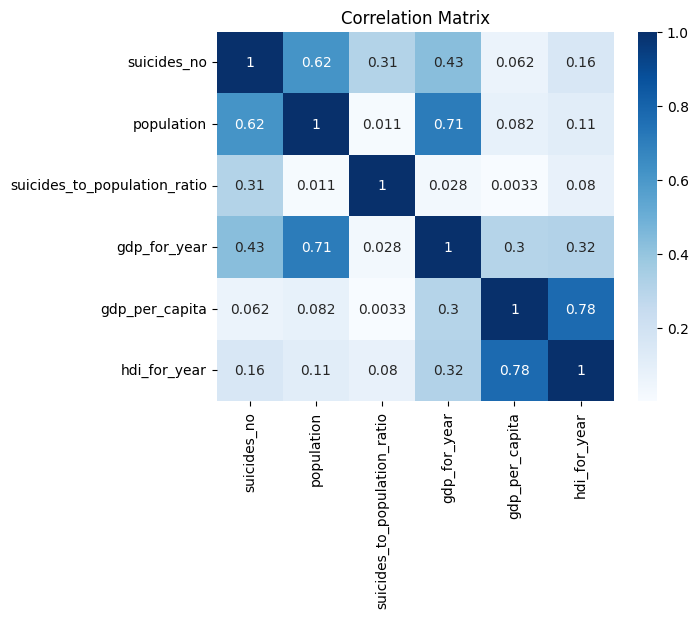

In [24]:
correlation = df[numerical_columns_country_year + numerical_columns_country].corr()

sns.heatmap(correlation, annot=True, cmap='Blues')
plt.title('Correlation Matrix')

Eksplorimi i Relacioneve Multivariante në të Dhënat e Vetëvrasjeve dhe Popullsisë me Pairplot

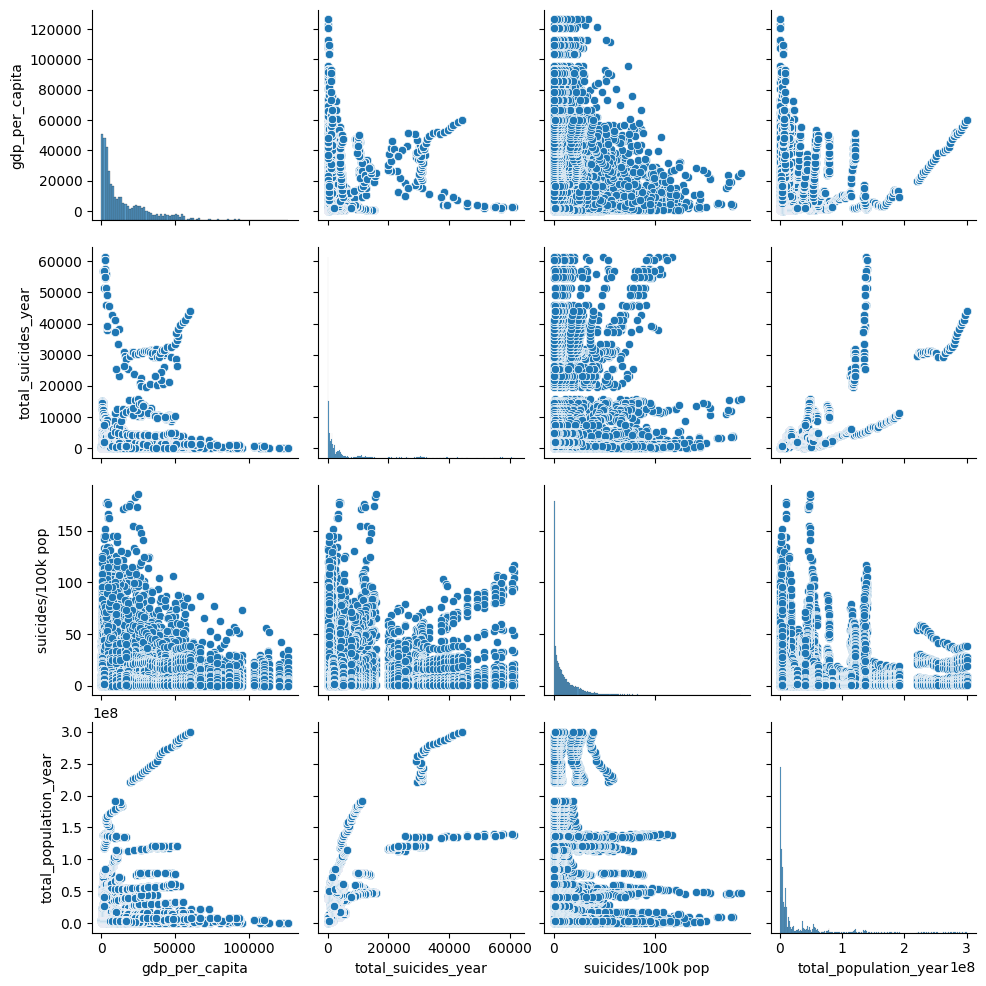

In [6]:
# Select numeric columns for the pairplot
numeric_columns = ['gdp_per_capita', 'total_suicides_year', 'suicides/100k pop', 'total_population_year']

# Create the pairplot
sns.pairplot(df[numeric_columns])
plt.show()

Shperndarja e popullsise pas log-transformimit

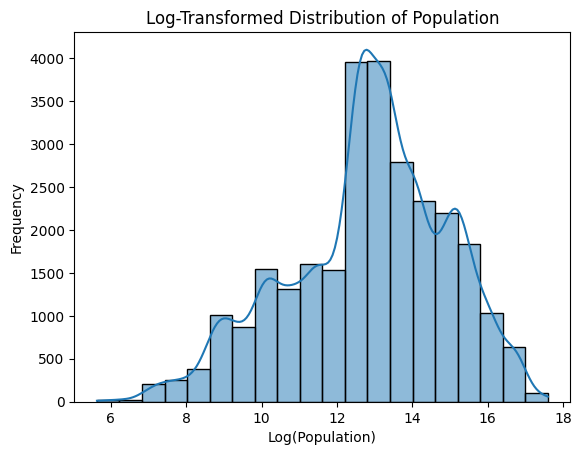

In [8]:
df['log_population'] = np.log(df['population'] + 1)

sns.histplot(df['log_population'], bins=20, kde=True)
plt.title('Log-Transformed Distribution of Population')
plt.xlabel('Log(Population)')
plt.ylabel('Frequency')
plt.show()

Shperndarja e rasteve ne base te grupe-moshave

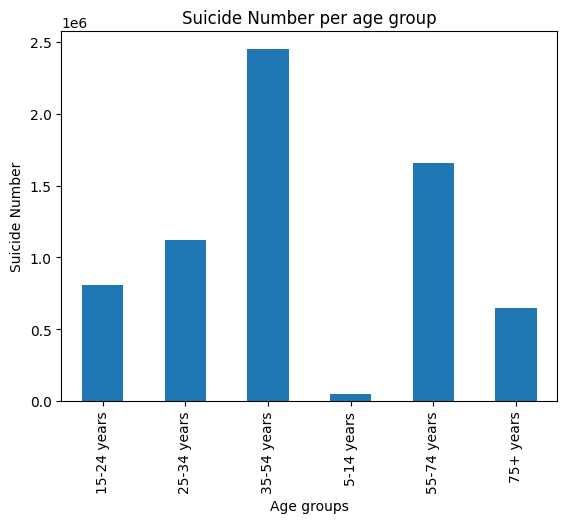

In [9]:
age_suicidal_no = df.groupby('age')['suicides_no'].sum()

# Plot the aggregated data
age_suicidal_no.plot(kind='bar')
plt.xlabel('Age groups')
plt.ylabel('Suicide Number')
plt.title('Suicide Number per age group')
plt.show()